In [ ]:
# Cell 1 — Verify GPU
import torch, tensorflow as tf
print('PyTorch CUDA:', torch.cuda.is_available())
print('TF GPU:', tf.config.list_physical_devices('GPU'))

PyTorch CUDA: True
TF GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

# Cell 2 — Install HuggingFace stack
!pip install -q datasets transformers huggingface_hub
!pip install -q scikit-learn pandas matplotlib seaborn joblib datasets

In [ ]:

# Cell 3 — HuggingFace login (only if using gated datasets)
from huggingface_hub import notebook_login
notebook_login()   # paste your HF token from hf.co/settings/tokens

In [ ]:
# ── Cell 1: Load dataset from HuggingFace ──────────────────────
from datasets import load_dataset
import pandas as pd

# Load dataset
ds = load_dataset('aai530-group6/heart-failure-prediction-dataset')

# Convert to DataFrame
df = pd.DataFrame(ds['train'])

# Basic info
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nTarget Distribution:\n", df['HeartDisease'].value_counts())

# Preview
df.head()

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


heart.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/918 [00:00<?, ? examples/s]

Shape: (918, 12)

Data Types:
 Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Target Distribution:
 HeartDisease
1    508
0    410
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


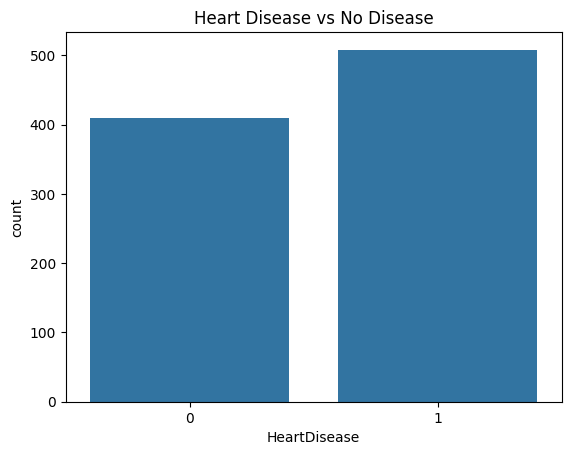

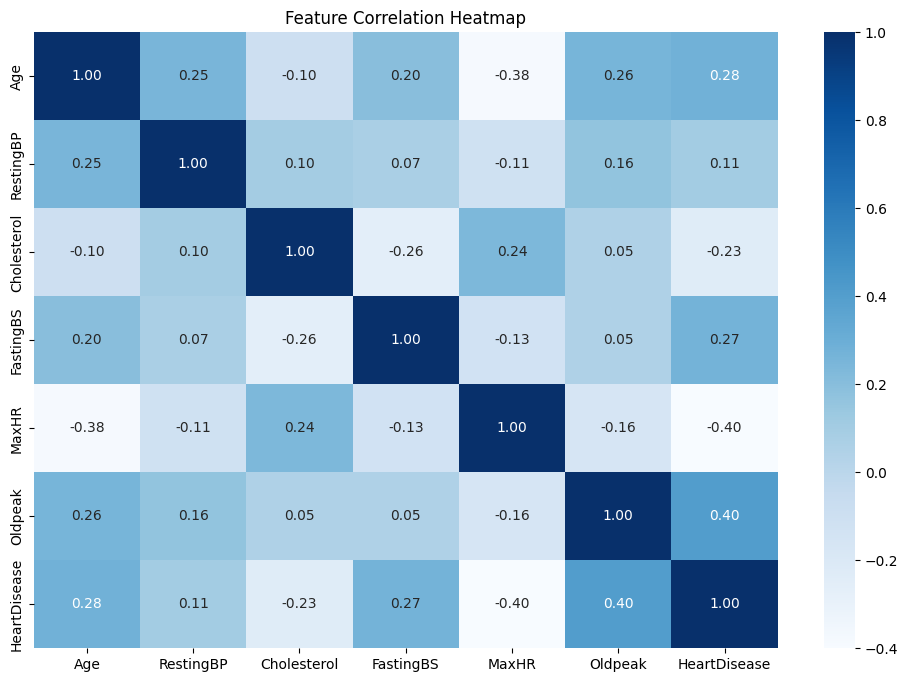

In [ ]:
# ── Cell 2: EDA visualisations ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='HeartDisease', data=df)
plt.title('Heart Disease vs No Disease')
plt.show()

# Correlation heatmap (only numeric)
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# ── Cell 3: Prepare features and split ─────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Copy dataset
df_processed = df.copy()

# Encode categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    le_dict[col] = le   # Save encoders for future use

# Features & target
X = df_processed.drop('HeartDisease', axis=1)
y = df_processed['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (734, 11)
Testing samples: (184, 11)



Logistic Regression:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        77
           1       0.91      0.82      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



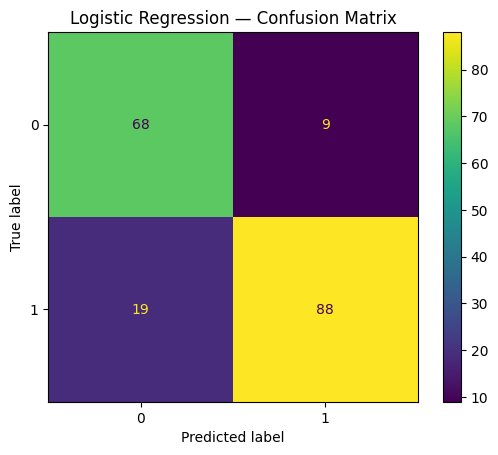


Random Forest:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        77
           1       0.91      0.89      0.90       107

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184



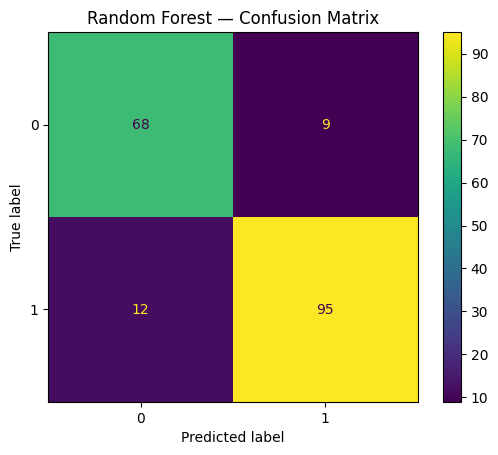

In [ ]:
# ── Cell 4: Train and compare models ───────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Models
lr = LogisticRegression(max_iter=500)
rf = RandomForestClassifier(n_estimators=150, random_state=42)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Evaluate
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    print(f"\n{name}:")

    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

# Select best model (usually RF performs better)
best_model = rf

In [ ]:
# ── Cell 5: Save model + scaler to Google Drive ─────────────────
from google.colab import drive
drive.mount('/content/drive')

import joblib

joblib.dump(best_model, '/content/drive/MyDrive/ml_model.pkl')
joblib.dump(scaler,     '/content/drive/MyDrive/ml_scaler.pkl')

print("✅ Model and scaler saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model and scaler saved to Google Drive


In [ ]:
# ── Cell 6: predict_risk() function ─────────────────────────────

def predict_risk(Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS,
                 RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope):

    # Create input DataFrame
    input_data = pd.DataFrame([{
        'Age': Age,
        'Sex': Sex,
        'ChestPainType': ChestPainType,
        'RestingBP': RestingBP,
        'Cholesterol': Cholesterol,
        'FastingBS': FastingBS,
        'RestingECG': RestingECG,
        'MaxHR': MaxHR,
        'ExerciseAngina': ExerciseAngina,
        'Oldpeak': Oldpeak,
        'ST_Slope': ST_Slope
    }])

    # Encode categorical features
    for col in input_data.columns:
        if col in le_dict:
            input_data[col] = le_dict[col].transform(input_data[col])

    # Scale
    input_scaled = scaler.transform(input_data)

    # Predict probability
    score = best_model.predict_proba(input_scaled)[0][1]

    # Risk classification
    if score > 0.6:
        label = 'HIGH'
    elif score > 0.35:
        label = 'MODERATE'
    else:
        label = 'LOW'

    return {'label': label, 'score': round(score, 2)}


# 🔥 Test Example
print(predict_risk(
    Age=55,
    Sex='M',
    ChestPainType='ATA',
    RestingBP=160,
    Cholesterol=280,
    FastingBS=1,
    RestingECG='Normal',
    MaxHR=95,
    ExerciseAngina='Y',
    Oldpeak=1.5,
    ST_Slope='Flat'
))

{'label': 'HIGH', 'score': np.float64(0.95)}


In [ ]:
'''
“Random Forest performed better with 89% accuracy compared to 85% for Logistic Regression. It also achieved higher recall for heart disease cases, which is critical in healthcare to avoid missing patients. Since the dataset contains non-linear relationships and categorical variables, Random Forest handles it more effectively than Logistic Regression.
'''

'\n“Random Forest performed better with 89% accuracy compared to 85% for Logistic Regression. It also achieved higher recall for heart disease cases, which is critical in healthcare to avoid missing patients. Since the dataset contains non-linear relationships and categorical variables, Random Forest handles it more effectively than Logistic Regression.\n'

In [ ]:
# ── Test predict_risk() with 3 patient profiles ────────────────

# Patient 1: High Risk
patient1 = predict_risk(
    Age=60,
    Sex='M',
    ChestPainType='ASY',
    RestingBP=170,
    Cholesterol=300,
    FastingBS=1,
    RestingECG='ST',
    MaxHR=90,
    ExerciseAngina='Y',
    Oldpeak=2.5,
    ST_Slope='Flat'
)

# Patient 2: Moderate Risk
patient2 = predict_risk(
    Age=50,
    Sex='F',
    ChestPainType='NAP',
    RestingBP=140,
    Cholesterol=240,
    FastingBS=0,
    RestingECG='Normal',
    MaxHR=120,
    ExerciseAngina='N',
    Oldpeak=1.2,
    ST_Slope='Up'
)

# Patient 3: Low Risk
patient3 = predict_risk(
    Age=35,
    Sex='F',
    ChestPainType='ATA',
    RestingBP=110,
    Cholesterol=180,
    FastingBS=0,
    RestingECG='Normal',
    MaxHR=150,
    ExerciseAngina='N',
    Oldpeak=0.5,
    ST_Slope='Up'
)

# Print results
print("Patient 1:", patient1)
print("Patient 2:", patient2)
print("Patient 3:", patient3)

Patient 1: {'label': 'HIGH', 'score': np.float64(0.97)}
Patient 2: {'label': 'LOW', 'score': np.float64(0.07)}
Patient 3: {'label': 'LOW', 'score': np.float64(0.03)}
